# Quiz 1

In [6]:
import os
import sys
from importlib import reload

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
import shutil
import kagglehub

In [ ]:
# 1. 下載資料集到本地快取
cache_path = kagglehub.dataset_download("abdallahwagih/emotion-dataset")
print("Kaggle 快取路徑:", cache_path)

# 2. 定義目標資料夾路徑
target_dir = "data"
os.makedirs(target_dir, exist_ok=True)

# 3. 將快取內的資料夾與檔案同步至 data/
for item in os.listdir(cache_path):
    src = os.path.join(cache_path, item)
    dst = os.path.join(target_dir, item)
    if os.path.isdir(src):
        # dirs_exist_ok=True 確保目標資料夾存在時也能覆蓋/更新內容
        shutil.copytree(src, dst, dirs_exist_ok=True)
    else:
        shutil.copy2(src, dst)

print("同步完成！目前 data 資料夾內容:", os.listdir(target_dir))

In [ ]:
# 1. 下載資料集到本地快取
cache_path = kagglehub.dataset_download("ananthu017/emotion-detection-fer")
print("Kaggle 快取路徑:", cache_path)

# 2. 定義目標資料夾路徑
target_dir = "data"
os.makedirs(target_dir, exist_ok=True)

# 3. 將快取內的資料夾與檔案同步至 data/
for item in os.listdir(cache_path):
    src = os.path.join(cache_path, item)
    dst = os.path.join(target_dir, item)
    if os.path.isdir(src):
        # dirs_exist_ok=True 確保目標資料夾存在時也能覆蓋/更新內容
        shutil.copytree(src, dst, dirs_exist_ok=True)
    else:
        shutil.copy2(src, dst)

print("同步完成！目前 data 資料夾內容:", os.listdir(target_dir))

# Quiz 2

## 資料前處理：讀取資料、Train : Valid = 8 : 2

- 資料：`data/Emotion_classify_Data.csv`，輸入為一段英文描述（`Comment`），輸出為情緒類別（`Emotion`：anger / fear / joy）
- 去除空值與重複句子後，以情緒類別做**分層抽樣**切成 Train : Valid = 8 : 2，確保兩邊的類別比例一致
- 字典（Vocab）**只用 Train 建立**，避免 Valid 的資訊洩漏；出現次數 < 2 的詞與字典外的詞都視為 `<unk>`

In [7]:
# 讓 notebook 不論從哪個目錄啟動，都找得到 Code 套件
BASE_DIR = os.path.abspath('')
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

import torch
import Code.quiz2 as q2
reload(q2)

RANDOM_STATE = 42                 # 固定亂數種子，確保結果可重現
q2.set_seed(RANDOM_STATE)
device = q2.get_device()
print('device:', device)

CSV_PATH = os.path.join(BASE_DIR, 'data', 'Emotion_classify_Data.csv')
df = q2.load_data(CSV_PATH)
print('資料筆數:', len(df))
display(df.head())
display(df['label'].value_counts().to_frame('count'))

device: cuda
資料筆數: 5934


,text,label
0,i seriously hate one subject to death but now ...,fear
1,im so full of life i feel appalled,anger
2,i sit here to write i start to dig out my feel...,fear
3,ive been really angry with r and i feel like a...,joy
4,i feel suspicious if there is no one outside l...,fear


,count
label,
anger,2000
joy,2000
fear,1934


In [8]:
# 分層抽樣切分 Train : Valid = 8 : 2
train_df, valid_df = q2.split_train_valid(df, valid_size=0.2, random_state=RANDOM_STATE)

CLASS_NAMES = sorted(df['label'].unique())
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)

split_summary = pd.DataFrame({
    'train': train_df['label'].value_counts(),
    'valid': valid_df['label'].value_counts(),
}).loc[CLASS_NAMES]
split_summary.loc['total'] = split_summary.sum()
split_summary['valid ratio'] = (split_summary['valid'] / split_summary.sum(axis=1)).round(3)
display(split_summary)

,train,valid,valid ratio
label,,,
anger,1600,400,0.2
fear,1547,387,0.2
joy,1600,400,0.2
total,4747,1187,0.2


count    4747.0
mean       19.0
std        11.0
min         2.0
25%        11.0
50%        17.0
75%        25.0
max        64.0
Name: text, dtype: float64


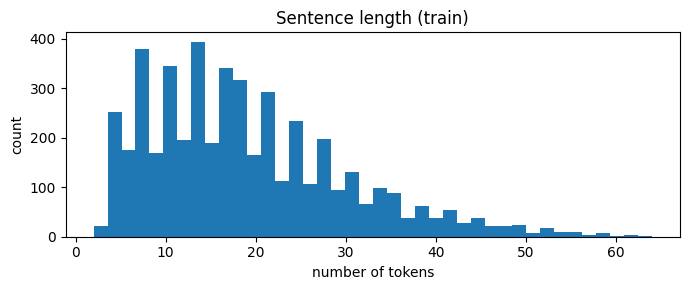

In [9]:
# 句子長度（詞數）分佈 → 決定序列最大長度 MAX_LEN
lengths = train_df['text'].map(lambda t: len(q2.tokenize(t)))
print(lengths.describe().round(1))

plt.figure(figsize=(7, 3))
plt.hist(lengths, bins=40)
plt.xlabel('number of tokens')
plt.ylabel('count')
plt.title('Sentence length (train)')
plt.tight_layout()
plt.show()

In [10]:
MAX_LEN = 64          # 最長句子約 64 個詞，幾乎不會截斷
BATCH_SIZE = 64

vocab = q2.Vocab(train_df['text'], min_freq=2)
print('字典大小:', len(vocab))
print('範例:', train_df['text'][0])
print('編碼:', vocab.encode(train_df['text'][0], MAX_LEN))

loaders = q2.build_dataloaders(train_df, valid_df, vocab, CLASS_TO_IDX, max_len=MAX_LEN, batch_size=BATCH_SIZE)
print('train batches:', len(loaders['train']), '| valid batches:', len(loaders['valid']))

字典大小: 3458
範例: i feel like watching a show or a movie after the kids are in bed i make sure to hop on my elliptical or spin bike for at least minutes of the show before i settle down and stretch out for the night
編碼: [2, 3, 14, 588, 7, 317, 32, 7, 516, 187, 6, 327, 45, 12, 448, 2, 92, 155, 5, 2351, 31, 11, 1, 32, 1816, 965, 21, 34, 318, 589, 10, 6, 317, 144, 2, 1168, 145, 4, 1817, 51, 21, 6, 253]
train batches: 75 | valid batches: 19


## 模型：RNN vs. LSTM

兩個模型使用**完全相同**的架構與超參數，只差在循環層是 `nn.RNN` 還是 `nn.LSTM`，比較才公平：

`Embedding(128)` → 2 層雙向 `RNN / LSTM`(hidden 128) → 取最後一層正反兩方向的 hidden state 串接 → `Dropout(0.3)` → `FC(3)`

- 使用 `pack_padded_sequence`，讓模型只看每句話的真實長度，`<pad>` 不會影響最後的 hidden state
- 訓練：Adam(lr=1e-3) + CrossEntropy，Gradient Clipping（避免 RNN 梯度爆炸）、ReduceLROnPlateau
- 以 **Valid Macro-F1** 選最佳權重並做 Early Stopping

In [11]:
MODEL_DIR = os.path.join(BASE_DIR, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_KWARGS = dict(embed_dim=128, hidden_dim=128, num_layers=2, bidirectional=True, dropout=0.3)
TRAIN_KWARGS = dict(epochs=30, lr=1e-3, weight_decay=1e-5, clip_norm=1.0, patience=6)

for rnn_type in ['rnn', 'lstm']:
    m = q2.TextRNN(len(vocab), NUM_CLASSES, rnn_type=rnn_type, **MODEL_KWARGS)
    print(f'{rnn_type.upper():4s} 參數量: {q2.count_parameters(m) / 1e6:.3f} M')

RNN  參數量: 0.608 M
LSTM 參數量: 1.103 M


### 2-1 RNN 訓練

In [12]:
q2.set_seed(RANDOM_STATE)
rnn_model = q2.TextRNN(len(vocab), NUM_CLASSES, rnn_type='rnn', **MODEL_KWARGS)
rnn_model, rnn_hist = q2.train_model(
    rnn_model, loaders, device, save_path=os.path.join(MODEL_DIR, 'emotion_rnn.pt'), **TRAIN_KWARGS,
)

[RNN ] epoch  1 | loss 1.1221/1.0846 | acc 0.4997/0.3951 | f1 0.4974/0.3891 | 2.1s
[RNN ] epoch  2 | loss 1.0606/1.0675 | acc 0.5625/0.4372 | f1 0.5585/0.4332 | 1.8s
[RNN ] epoch  3 | loss 0.9959/1.0429 | acc 0.6172/0.4768 | f1 0.6118/0.4625 | 1.8s
[RNN ] epoch  4 | loss 0.9103/0.9694 | acc 0.7118/0.5307 | f1 0.7119/0.5301 | 1.8s
[RNN ] epoch  5 | loss 0.8456/0.9641 | acc 0.7403/0.5476 | f1 0.7394/0.5400 | 1.8s
[RNN ] epoch  6 | loss 0.7636/0.8921 | acc 0.7904/0.6234 | f1 0.7880/0.6168 | 1.8s
[RNN ] epoch  7 | loss 0.6984/0.8101 | acc 0.8475/0.6689 | f1 0.8469/0.6660 | 1.8s
[RNN ] epoch  8 | loss 0.6045/0.7324 | acc 0.8961/0.7009 | f1 0.8962/0.7014 | 1.9s
[RNN ] epoch  9 | loss 0.5426/0.6790 | acc 0.9136/0.7355 | f1 0.9135/0.7345 | 1.8s
[RNN ] epoch 10 | loss 0.4721/0.6116 | acc 0.9303/0.7692 | f1 0.9303/0.7695 | 2.6s
[RNN ] epoch 11 | loss 0.4284/0.6247 | acc 0.9520/0.7582 | f1 0.9521/0.7583 | 8.8s
[RNN ] epoch 12 | loss 0.3647/0.5660 | acc 0.9648/0.7987 | f1 0.9649/0.7978 | 8.9s
[RNN

### 2-2 LSTM 訓練

In [13]:
q2.set_seed(RANDOM_STATE)
lstm_model = q2.TextRNN(len(vocab), NUM_CLASSES, rnn_type='lstm', **MODEL_KWARGS)
lstm_model, lstm_hist = q2.train_model(
    lstm_model, loaders, device, save_path=os.path.join(MODEL_DIR, 'emotion_lstm.pt'), **TRAIN_KWARGS,
)

[LSTM] epoch  1 | loss 1.0829/1.0452 | acc 0.5315/0.4684 | f1 0.5323/0.4679 | 5.5s
[LSTM] epoch  2 | loss 0.9458/0.8353 | acc 0.7251/0.6184 | f1 0.7230/0.6152 | 8.5s
[LSTM] epoch  3 | loss 0.6873/0.6031 | acc 0.8616/0.7540 | f1 0.8624/0.7560 | 7.8s
[LSTM] epoch  4 | loss 0.4588/0.4001 | acc 0.9343/0.8433 | f1 0.9345/0.8437 | 8.2s
[LSTM] epoch  5 | loss 0.3199/0.3320 | acc 0.9503/0.8837 | f1 0.9503/0.8837 | 7.5s
[LSTM] epoch  6 | loss 0.2477/0.3072 | acc 0.9673/0.8863 | f1 0.9673/0.8862 | 8.1s
[LSTM] epoch  7 | loss 0.2065/0.2523 | acc 0.9800/0.9082 | f1 0.9800/0.9084 | 7.5s
[LSTM] epoch  8 | loss 0.1477/0.2303 | acc 0.9878/0.9225 | f1 0.9877/0.9225 | 8.5s
[LSTM] epoch  9 | loss 0.1375/0.2475 | acc 0.9897/0.9200 | f1 0.9897/0.9198 | 8.1s
[LSTM] epoch 10 | loss 0.1073/0.2843 | acc 0.9901/0.9082 | f1 0.9901/0.9087 | 8.2s
[LSTM] epoch 11 | loss 0.1035/0.2271 | acc 0.9943/0.9208 | f1 0.9943/0.9208 | 7.7s
[LSTM] epoch 12 | loss 0.0684/0.2198 | acc 0.9975/0.9284 | f1 0.9975/0.9283 | 8.8s
[LST

### 2-3 RNN vs. LSTM 表現比較

評估指標（皆在 Valid set 上計算）：
- **Accuracy**：整體預測正確的比例；三個類別數量接近（約各 1/3），Accuracy 具參考性
- **Macro Precision / Recall / F1**：每個類別分別計算後取平均，每個類別權重相同，能反映模型是否對某一類特別差；**Macro-F1 為主要比較指標**
- **Macro AUC（One-vs-Rest）**：看的是預測機率的排序能力，不受 argmax 門檻影響
- **混淆矩陣**：看哪兩種情緒最容易互相混淆
- **訓練曲線**：比較收斂速度與 overfitting 程度

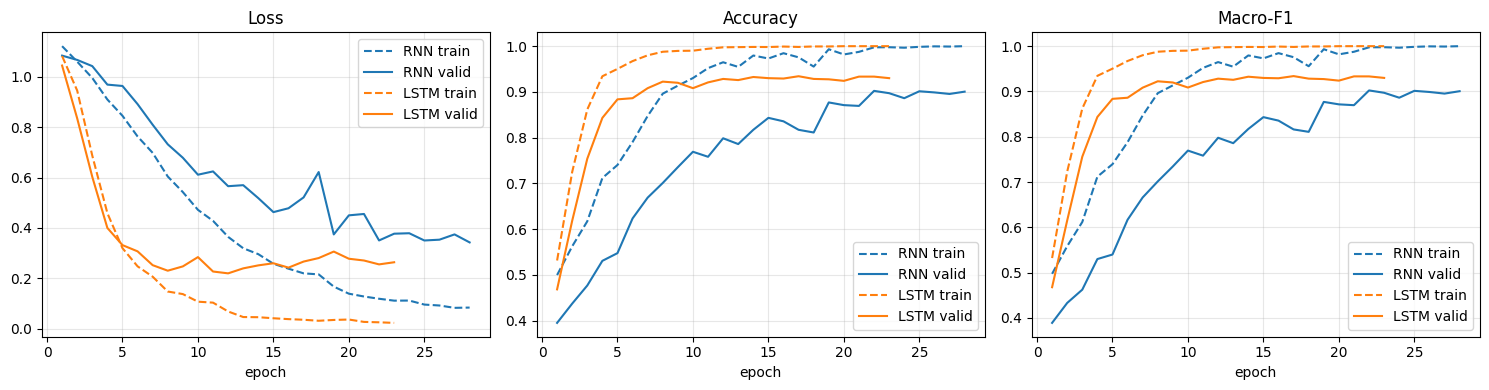

In [14]:
q2.plot_histories({'RNN': rnn_hist, 'LSTM': lstm_hist})

,accuracy,precision,recall,f1,auc,best epoch,epochs trained
RNN,0.9023,0.9033,0.9022,0.9023,0.9772,22,28
LSTM,0.9343,0.9352,0.9343,0.9339,0.9899,17,23


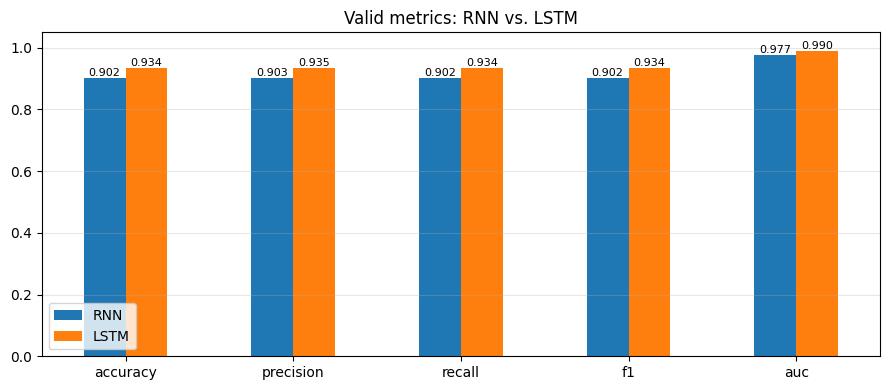

In [15]:
results = {
    'RNN': q2.predict_proba(rnn_model, loaders['valid'], device),
    'LSTM': q2.predict_proba(lstm_model, loaders['valid'], device),
}
compare_df = q2.compare_models(results)
compare_df['best epoch'] = [h['valid_f1'].idxmax() + 1 for h in (rnn_hist, lstm_hist)]
compare_df['epochs trained'] = [len(rnn_hist), len(lstm_hist)]
display(compare_df)

q2.plot_metric_bars(compare_df)

In [16]:
# 各類別的 Precision / Recall / F1
for name, (prob, y) in results.items():
    print(f'===== {name} =====')
    display(q2.report(y, prob, CLASS_NAMES))

===== RNN =====


,precision,recall,f1-score,support
anger,0.9046,0.8775,0.8909,400.0000
fear,0.9251,0.8941,0.9093,387.0000
joy,0.8800,0.9350,0.9067,400.0000
accuracy,0.9023,0.9023,0.9023,0.9023
macro avg,0.9033,0.9022,0.9023,1187.0000
weighted avg,0.9030,0.9023,0.9022,1187.0000


===== LSTM =====


,precision,recall,f1-score,support
anger,0.9595,0.8875,0.9221,400.0000
fear,0.9258,0.9354,0.9306,387.0000
joy,0.9202,0.9800,0.9492,400.0000
accuracy,0.9343,0.9343,0.9343,0.9343
macro avg,0.9352,0.9343,0.9339,1187.0000
weighted avg,0.9353,0.9343,0.9340,1187.0000


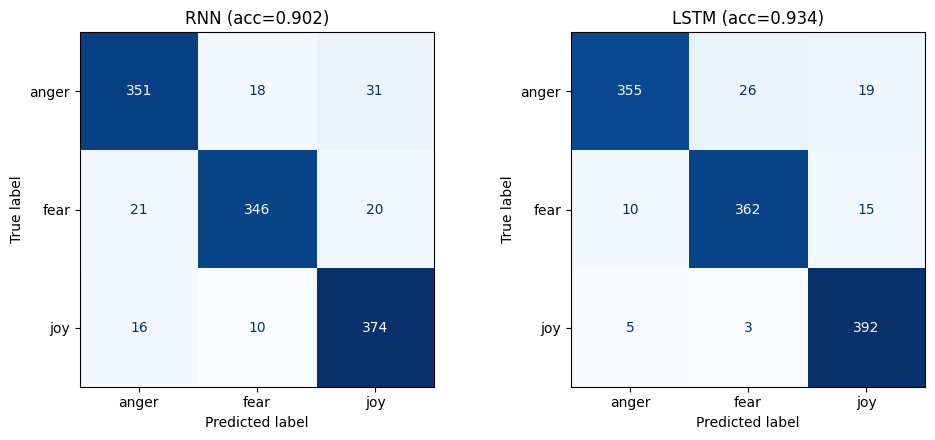

In [17]:
q2.plot_confusion_matrices(results, CLASS_NAMES)

### 結果討論

- **LSTM 整體表現優於 RNN**：Accuracy、Macro-F1、AUC 皆較高，且在較少的 epoch 內就達到最佳 Valid 表現
- **收斂速度**：RNN 的 Valid 曲線上升緩慢且震盪較大；LSTM 前幾個 epoch 就快速收斂。原因是 vanilla RNN 每一步都經過 tanh 與同一個權重矩陣相乘，長句子反向傳播時容易梯度消失 / 爆炸，較難記住句子前段的情緒詞；LSTM 的 cell state 加上 forget / input / output gate，讓梯度能較穩定地跨時間步傳遞
- **Overfitting**：兩者 Train Accuracy 都接近 100%，資料量僅約 4.7k 句且 Embedding 從頭訓練，Train–Valid 之間仍有落差；可再加大 Dropout、使用預訓練詞向量（GloVe）等方式改善
- **代價**：LSTM 參數量約為 RNN 的 1.8 倍（每個時間步有 4 組閘門權重），每個 epoch 稍慢，但換來明顯較好的表現
- 錯誤分析可以看到部分句子標註本身帶有雜訊（例如句中出現 angry 卻被標為 joy），也限制了模型的上限

> 以上觀察請對照實際執行的數字修改

## Gradio 互動介面

輸入一段英文句子，同時顯示 RNN 與 LSTM 對三種情緒的預測機率。

In [19]:
import gradio as gr

demo = q2.build_gradio_app(
    {'RNN': rnn_model, 'LSTM': lstm_model},
    vocab, CLASS_NAMES, device, max_len=MAX_LEN,
    examples=[
        ['i feel so happy and grateful for everything today'],
        ['i am furious that they ignored my complaint again'],
        ['i feel nervous and scared about the exam tomorrow'],
    ],
)
demo.launch()          # 關閉介面：demo.close()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


# Quiz 3

## 資料前處理：Train / Valid / Test 切分

- 資料：`data/Image Classification/`，48×48 灰階臉部表情，7 類（angry, disgusted, fearful, happy, neutral, sad, surprised）
- `train/` 以情緒類別**分層抽樣**切成 Train : Valid = 8 : 2（Valid 用來選最佳 epoch）；`test/` 完全不參與訓練，只用於最後的測試
- 類別明顯不平衡（disgusted 只佔約 1.5%），因此評估以 **Macro** 指標為主（每個類別權重相同），訓練時也加上類別權重
- 第一次讀取所有影像較慢，會快取成 `data/fer_*.npz`，之後直接讀快取

In [35]:
# 讓 notebook 不論從哪個目錄啟動，都找得到 Code 套件
BASE_DIR = os.path.abspath('')
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

import torch
import Code.quiz3 as q3
reload(q3)

RANDOM_STATE = 42
q3.set_seed(RANDOM_STATE)
device = q3.get_device()
print('device:', device)

IMG_DIR = os.path.join(BASE_DIR, 'data', 'Image Classification')
full_train_df = q3.list_image_files(os.path.join(IMG_DIR, 'train'))
test_df = q3.list_image_files(os.path.join(IMG_DIR, 'test'))

# train 資料夾分層切成 Train : Valid = 8 : 2
train_df, valid_df = q3.split_train_valid(full_train_df, valid_size=0.2, random_state=RANDOM_STATE)

IMG_CLASS_NAMES = sorted(full_train_df['label'].unique())
IMG_CLASS_TO_IDX = {c: i for i, c in enumerate(IMG_CLASS_NAMES)}
IMG_NUM_CLASSES = len(IMG_CLASS_NAMES)

img_summary = q3.split_summary({'train': train_df, 'valid': valid_df, 'test': test_df}, IMG_CLASS_NAMES)
display(img_summary)
print((img_summary.loc['total', ['train', 'valid']] / img_summary.loc['total', ['train', 'valid']].sum()).round(3))

device: cuda


,train,valid,test,total
label,,,,
angry,3196,799,958,4953
disgusted,349,87,111,547
fearful,3277,820,1024,5121
happy,5772,1443,1774,8989
neutral,3972,993,1233,6198
sad,3864,966,1247,6077
surprised,2537,634,831,4002
total,22967,5742,7178,35887


train    0.8
valid    0.2
Name: total, dtype: float64


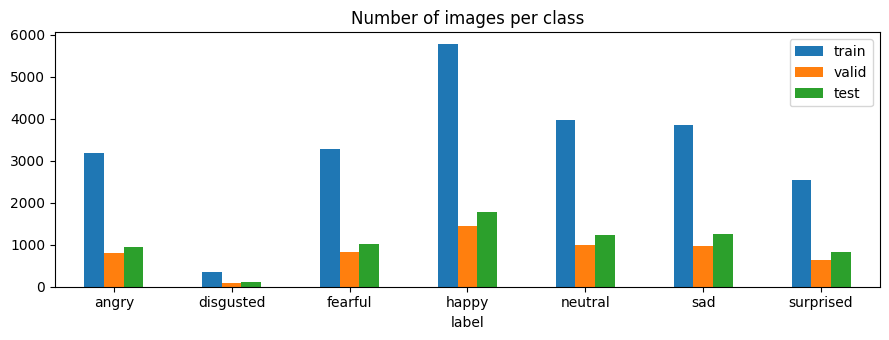

In [22]:
# 類別分佈（可以看出 disgusted 非常少）
img_summary.drop(index='total')[['train', 'valid', 'test']].plot(kind='bar', figsize=(9, 3.5), rot=0,
                                                                 title='Number of images per class')
plt.tight_layout()
plt.show()

In [23]:
%%time
# 讀取影像（灰階 uint8, N×1×48×48），第一次會建立快取
dfs = {'train': train_df, 'valid': valid_df, 'test': test_df}
images, targets = {}, {}
for split, d in dfs.items():
    images[split] = q3.load_images(d, cache_path=os.path.join(BASE_DIR, 'data', f'fer_{split}.npz'))
    targets[split] = torch.tensor([IMG_CLASS_TO_IDX[c] for c in d['label']], dtype=torch.long)
    print(f'{split:5s}', tuple(images[split].shape))

train (22967, 1, 48, 48)
valid (5742, 1, 48, 48)
test  (7178, 1, 48, 48)
CPU times: total: 10.6 s
Wall time: 34.4 s


## 模型：微調 ResNet-50 vs. Vision Transformer (ViT-B/16)

兩個模型都使用 torchvision 的 **ImageNet 預訓練權重**，只把最後的分類層換成 7 類，並以相同的資料、前處理與訓練設定微調（full fine-tuning）：

| | ResNet-50 | ViT-B/16 |
|---|---|---|
| 架構 | CNN：卷積 + 殘差連接，具 locality / 平移不變性等 inductive bias | 影像切成 16×16 patch → 12 層 Transformer Encoder（Self-Attention），以 [CLS] token 分類 |
| 分類層 | `fc` → Dropout + Linear(2048, 7) | `heads.head` → Dropout + Linear(768, 7) |
| Backbone LR | 1e-4 | 3e-5（Transformer 微調需要較小的 LR）|

共同設定：
- 前處理（在 GPU 上以整個 batch 進行）：48×48 灰階 → 隨機水平翻轉 / 旋轉 ±10° / 縮放 / 平移（僅 train）→ Resize 224×224 → 複製成 3 通道 → ImageNet 正規化
- AdamW（分類層 LR 為 backbone 的 10 倍）、1 epoch Linear Warmup + Cosine Decay、AMP 混合精度、Gradient Clipping
- Loss：CrossEntropy + Label Smoothing 0.1 + 類別權重（數量反比開根號，處理類別不平衡）
- 依 **Valid Macro-AUC** 選最佳權重，Early Stopping（patience = 3）
- `RESUME = True`：`models/` 裡已有訓練好的權重就直接載入，不重新訓練（想重新訓練請改成 False）

In [25]:
IMG_SIZE = 224
IMG_BATCH_SIZE = 64
RESUME = True
MODEL_DIR = os.path.join(BASE_DIR, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

img_loaders = q3.build_dataloaders(images, targets, batch_size=IMG_BATCH_SIZE)
weights = q3.class_weights(targets['train'], IMG_NUM_CLASSES)
display(pd.Series(weights.numpy().round(3), index=IMG_CLASS_NAMES, name='class weight').to_frame().T)

COMMON_KWARGS = dict(epochs=8, warmup_epochs=1, label_smoothing=0.1, weights=weights,
                     img_size=IMG_SIZE, patience=3, resume=RESUME)

,angry,disgusted,fearful,happy,neutral,sad,surprised
class weight,0.806,2.439,0.796,0.6,0.723,0.733,0.904


### 3-1 微調 ResNet-50

In [26]:
q3.set_seed(RANDOM_STATE)
resnet = q3.build_model('resnet50', num_classes=IMG_NUM_CLASSES)
print(f'ResNet-50 參數量: {q3.count_parameters(resnet) / 1e6:.2f} M')

resnet, resnet_hist = q3.train_model(
    resnet, img_loaders, device, lr=1e-4, weight_decay=0.01,
    save_path=os.path.join(MODEL_DIR, 'fer_resnet50.pt'), **COMMON_KWARGS,
)
display(resnet_hist.round(4))

ResNet-50 參數量: 23.52 M


c:\Users\Alan\anaconda3\envs\virtual_env\Lib\site-packages\torch\optim\lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


epoch  1 | loss 1.7947/1.2522 | acc 0.3653/0.5538 | valid F1 0.4731 | valid AUC 0.8489 | 249s
epoch  2 | loss 1.4296/1.0960 | acc 0.5872/0.6099 | valid F1 0.5615 | valid AUC 0.8923 | 268s
epoch  3 | loss 1.2953/0.9814 | acc 0.6498/0.6522 | valid F1 0.6182 | valid AUC 0.9097 | 316s
epoch  4 | loss 1.2036/1.0027 | acc 0.6941/0.6552 | valid F1 0.6296 | valid AUC 0.9161 | 285s
epoch  5 | loss 1.1165/0.9300 | acc 0.7346/0.6761 | valid F1 0.6442 | valid AUC 0.9208 | 309s
epoch  6 | loss 1.0487/0.9235 | acc 0.7660/0.6787 | valid F1 0.6567 | valid AUC 0.9205 | 315s
epoch  7 | loss 1.0009/0.9240 | acc 0.7895/0.6834 | valid F1 0.6617 | valid AUC 0.9197 | 319s
epoch  8 | loss 0.9745/0.9297 | acc 0.8055/0.6818 | valid F1 0.6595 | valid AUC 0.9189 | 319s
Early stopping at epoch 8（最佳 Valid Macro-AUC = 0.9208）


,epoch,train_loss,valid_loss,train_acc,valid_acc,valid_f1,valid_auc,lr,time
0,1,1.7947,1.2522,0.3653,0.5538,0.4731,0.8489,0.0001,248.8441
1,2,1.4296,1.0960,0.5872,0.6099,0.5615,0.8923,0.0001,268.2063
2,3,1.2953,0.9814,0.6498,0.6522,0.6182,0.9097,0.0001,315.6884
3,4,1.2036,1.0027,0.6941,0.6552,0.6296,0.9161,0.0001,284.6938
4,5,1.1165,0.9300,0.7346,0.6761,0.6442,0.9208,0.0000,309.4597
5,6,1.0487,0.9235,0.7660,0.6787,0.6567,0.9205,0.0000,315.3034
6,7,1.0009,0.9240,0.7895,0.6834,0.6617,0.9197,0.0000,319.4146
7,8,0.9745,0.9297,0.8055,0.6818,0.6595,0.9189,0.0000,318.8191


### 3-2 微調 Vision Transformer (ViT-B/16)

In [27]:
q3.set_seed(RANDOM_STATE)
vit = q3.build_model('vit_b_16', num_classes=IMG_NUM_CLASSES)
print(f'ViT-B/16 參數量: {q3.count_parameters(vit) / 1e6:.2f} M')

vit, vit_hist = q3.train_model(
    vit, img_loaders, device, lr=3e-5, weight_decay=0.05,
    save_path=os.path.join(MODEL_DIR, 'fer_vit_b_16.pt'), **COMMON_KWARGS,
)
display(vit_hist.round(4))

ViT-B/16 參數量: 85.80 M
epoch  1 | loss 1.6649/1.0954 | acc 0.4514/0.6001 | valid F1 0.5138 | valid AUC 0.8907 | 304s
epoch  2 | loss 1.3701/1.0440 | acc 0.6154/0.6252 | valid F1 0.5887 | valid AUC 0.9101 | 291s
epoch  3 | loss 1.2642/0.9895 | acc 0.6643/0.6581 | valid F1 0.6362 | valid AUC 0.9159 | 292s
epoch  4 | loss 1.1805/0.9634 | acc 0.7014/0.6627 | valid F1 0.6290 | valid AUC 0.9200 | 290s
epoch  5 | loss 1.1033/0.9394 | acc 0.7415/0.6825 | valid F1 0.6518 | valid AUC 0.9211 | 288s
epoch  6 | loss 1.0331/0.8956 | acc 0.7772/0.6919 | valid F1 0.6724 | valid AUC 0.9217 | 266s
epoch  7 | loss 0.9769/0.9028 | acc 0.8053/0.6898 | valid F1 0.6697 | valid AUC 0.9194 | 284s
epoch  8 | loss 0.9493/0.9001 | acc 0.8203/0.6951 | valid F1 0.6763 | valid AUC 0.9197 | 291s


,epoch,train_loss,valid_loss,train_acc,valid_acc,valid_f1,valid_auc,lr,time
0,1,1.6649,1.0954,0.4514,0.6001,0.5138,0.8907,0.0,303.6435
1,2,1.3701,1.0440,0.6154,0.6252,0.5887,0.9101,0.0,290.7178
2,3,1.2642,0.9895,0.6643,0.6581,0.6362,0.9159,0.0,292.4196
3,4,1.1805,0.9634,0.7014,0.6627,0.6290,0.9200,0.0,290.1455
4,5,1.1033,0.9394,0.7415,0.6825,0.6518,0.9211,0.0,288.1349
5,6,1.0331,0.8956,0.7772,0.6919,0.6724,0.9217,0.0,266.2375
6,7,0.9769,0.9028,0.8053,0.6898,0.6697,0.9194,0.0,283.9016
7,8,0.9493,0.9001,0.8203,0.6951,0.6763,0.9197,0.0,291.1502


### 3-3 Testing Dataset 推論與比較

在完全沒參與訓練的 `test/` 上推論，比較指標：
- **Macro-AUC（One-vs-Rest）**：每個類別各自當作正類計算 ROC-AUC 再平均，衡量預測機率的排序能力，不受 argmax 門檻與類別不平衡影響，為**主要比較指標**
- **Accuracy**、**Macro Precision / Recall / F1**：類別不平衡時 Accuracy 會被 happy 等大類主導，Macro 指標讓每個類別權重相同
- 各類別 AUC、ROC Curve、混淆矩陣：看哪些情緒容易被混淆
- 參數量與推論速度：模型的成本

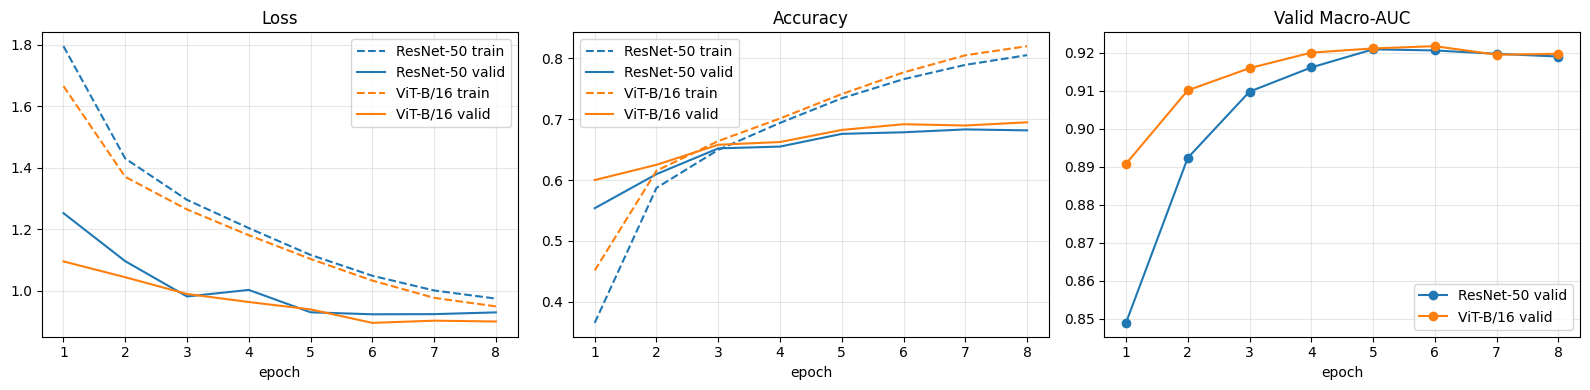

In [28]:
q3.plot_histories({'ResNet-50': resnet_hist, 'ViT-B/16': vit_hist})

,accuracy,macro_precision,macro_recall,macro_f1,macro_auc,params (M),infer (ms/img),best epoch
ResNet-50,0.6726,0.6281,0.6622,0.6344,0.9135,23.52,1.660,5
ViT-B/16,0.6893,0.6684,0.6702,0.6648,0.9219,85.80,4.255,6


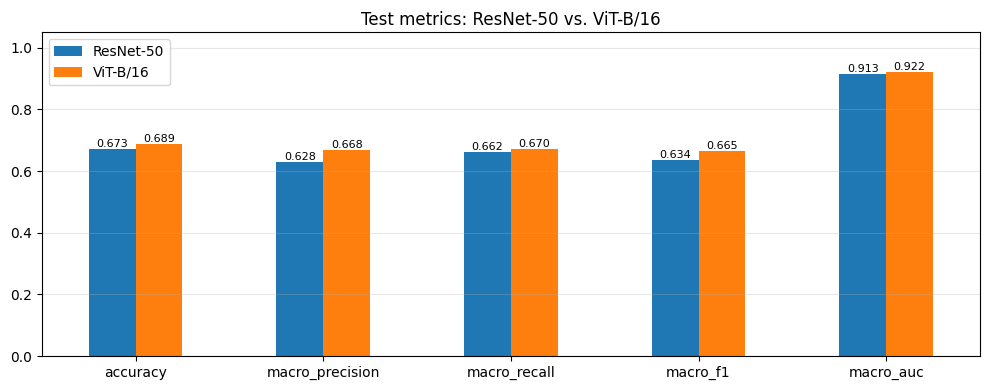

In [29]:
img_models = {'ResNet-50': resnet, 'ViT-B/16': vit}
img_results = {name: q3.predict_proba(m, img_loaders['test'], device, IMG_SIZE) for name, m in img_models.items()}

img_compare = q3.compare_models(img_results)
img_compare['params (M)'] = [round(q3.count_parameters(m) / 1e6, 2) for m in img_models.values()]
img_compare['infer (ms/img)'] = [round(q3.measure_inference_time(m, device, IMG_SIZE), 3) for m in img_models.values()]
img_compare['best epoch'] = [h['valid_auc'].idxmax() + 1 if not h.empty else None for h in (resnet_hist, vit_hist)]
display(img_compare)

q3.plot_metric_bars(img_compare, title='Test metrics: ResNet-50 vs. ViT-B/16')

,ResNet-50,ViT-B/16
angry,0.8948,0.9080
disgusted,0.9387,0.9457
fearful,0.8444,0.8582
happy,0.9748,0.9787
neutral,0.9040,0.9185
sad,0.8708,0.8775
surprised,0.9671,0.9669
macro,0.9135,0.9219


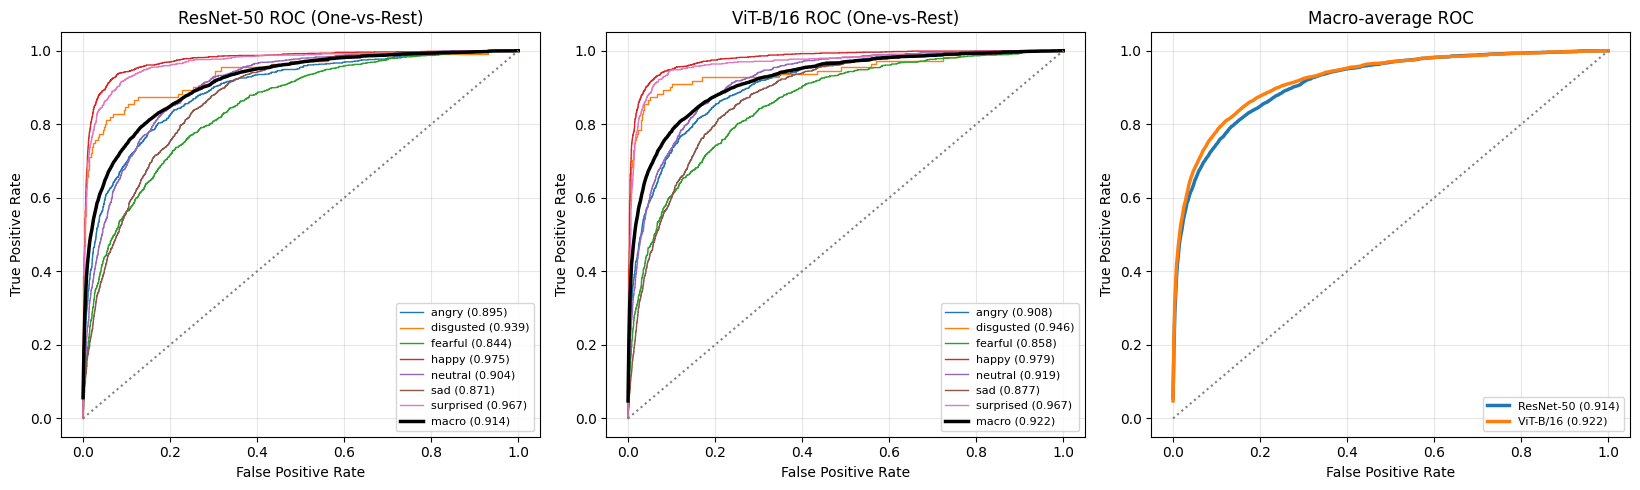

In [30]:
# 各類別 One-vs-Rest AUC（最後一列為 Macro-AUC）
display(q3.per_class_auc(img_results, IMG_CLASS_NAMES))

q3.plot_roc_curves(img_results, IMG_CLASS_NAMES)

In [31]:
# 各類別的 Precision / Recall / F1
for name, (prob, y) in img_results.items():
    print(f'===== {name} =====')
    display(q3.report(y, prob, IMG_CLASS_NAMES))

===== ResNet-50 =====


,precision,recall,f1-score,support
angry,0.6508,0.5699,0.6077,958.0000
disgusted,0.3873,0.7117,0.5016,111.0000
fearful,0.5939,0.4014,0.4790,1024.0000
happy,0.8779,0.8715,0.8747,1774.0000
neutral,0.5844,0.6991,0.6366,1233.0000
sad,0.5324,0.5670,0.5491,1247.0000
surprised,0.7702,0.8147,0.7918,831.0000
accuracy,0.6726,0.6726,0.6726,0.6726
macro avg,0.6281,0.6622,0.6344,7178.0000
weighted avg,0.6766,0.6726,0.6698,7178.0000


===== ViT-B/16 =====


,precision,recall,f1-score,support
angry,0.5936,0.6420,0.6169,958.0000
disgusted,0.6330,0.6216,0.6273,111.0000
fearful,0.5959,0.4521,0.5142,1024.0000
happy,0.9068,0.8664,0.8861,1774.0000
neutral,0.5790,0.7551,0.6554,1233.0000
sad,0.6128,0.4988,0.5500,1247.0000
surprised,0.7580,0.8556,0.8038,831.0000
accuracy,0.6893,0.6893,0.6893,0.6893
macro avg,0.6684,0.6702,0.6648,7178.0000
weighted avg,0.6918,0.6893,0.6856,7178.0000


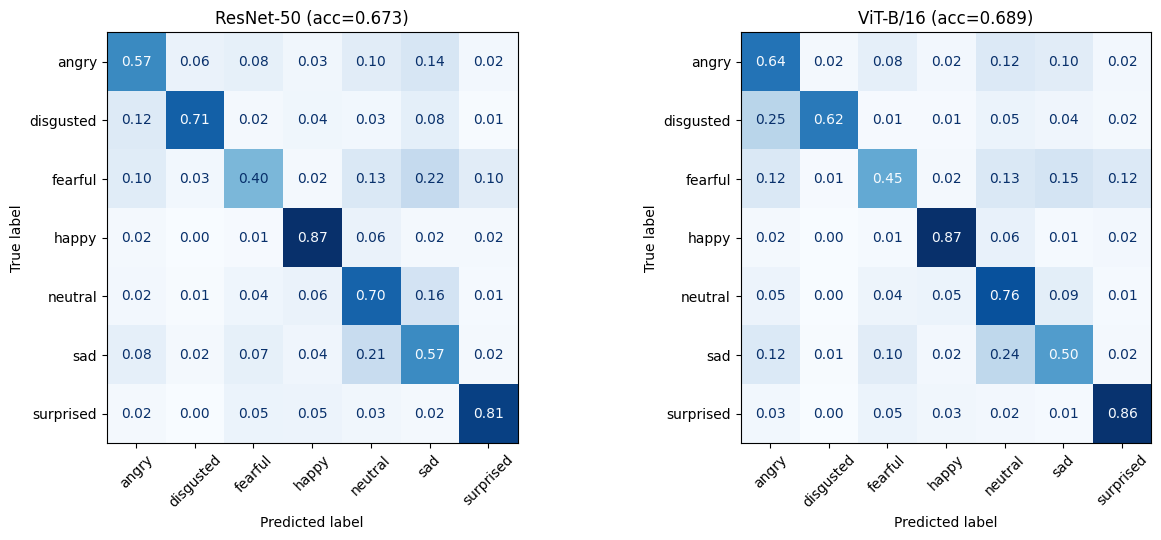

In [32]:
# 混淆矩陣（以列正規化 = 各類別的 Recall）
q3.plot_confusion_matrices(img_results, IMG_CLASS_NAMES)

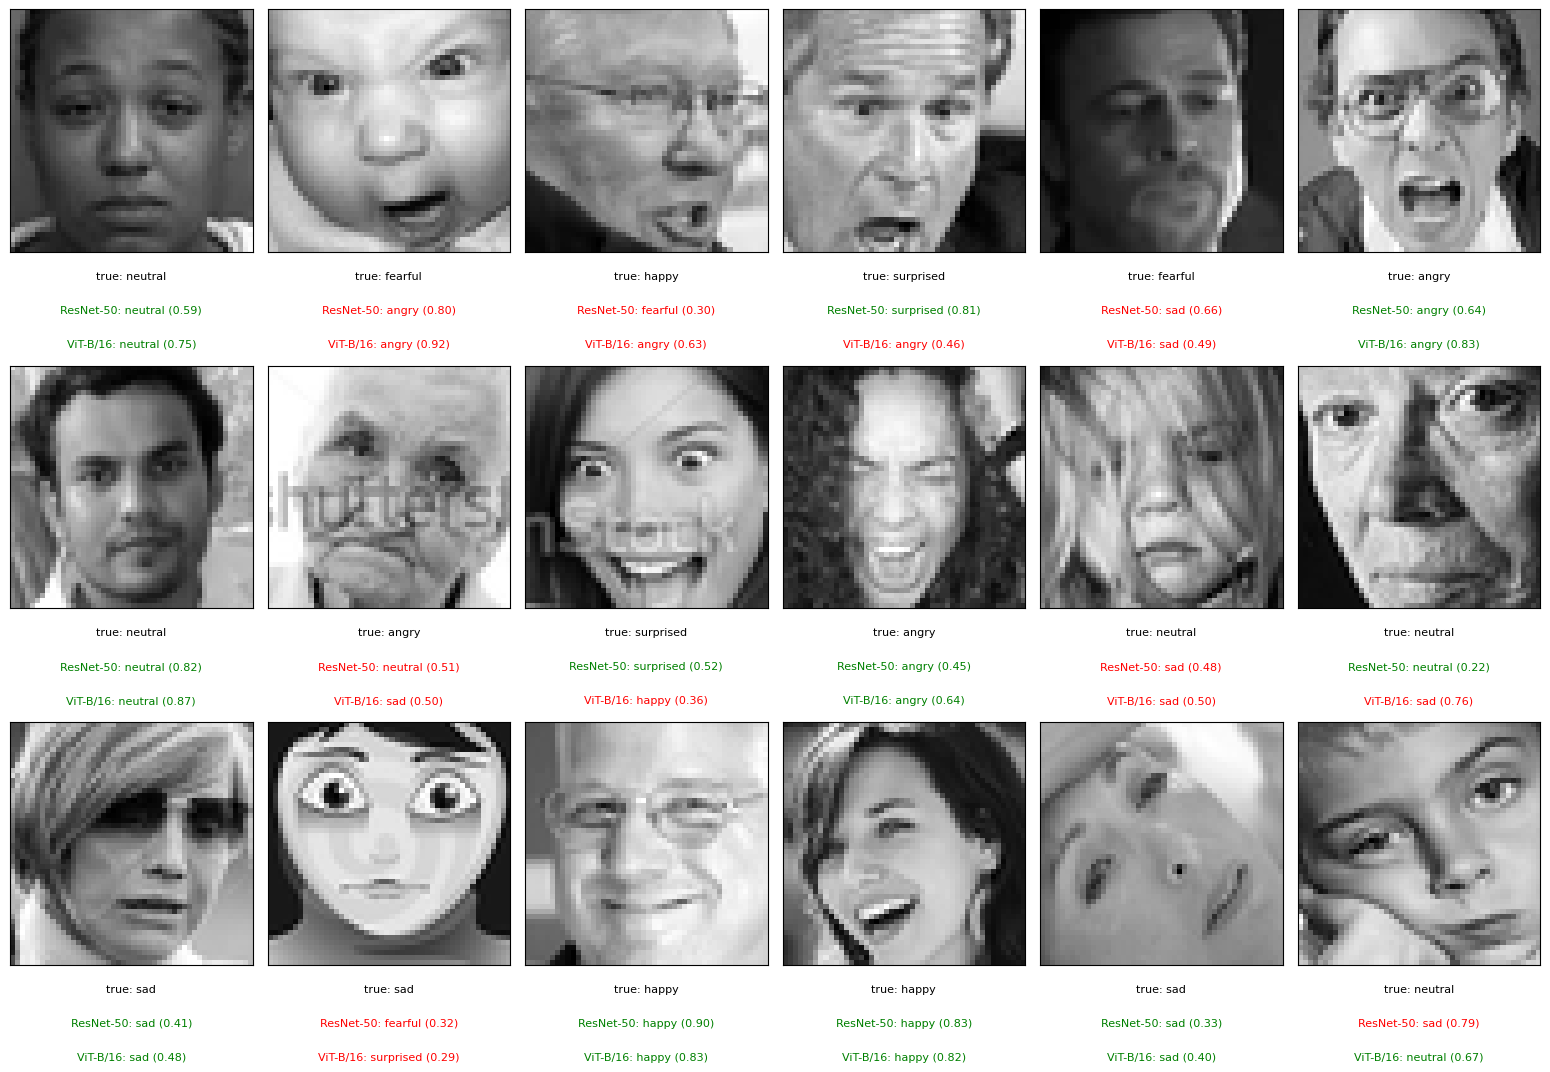

In [36]:
# 隨機挑選測試影像，比較兩個模型的預測（綠 = 正確、紅 = 錯誤）
q3.show_predictions(images['test'], img_results, IMG_CLASS_NAMES, n=18)

In [34]:
# 加分：Test-Time Augmentation（原圖 + 水平翻轉的預測取平均）
tta_results = {f'{name} + TTA': q3.predict_proba(m, img_loaders['test'], device, IMG_SIZE, tta=True)
               for name, m in img_models.items()}
display(q3.compare_models({**img_results, **tta_results}))

,accuracy,macro_precision,macro_recall,macro_f1,macro_auc
ResNet-50,0.6726,0.6281,0.6622,0.6344,0.9135
ViT-B/16,0.6893,0.6684,0.6702,0.6648,0.9219
ResNet-50 + TTA,0.6801,0.6372,0.6720,0.6434,0.9178
ViT-B/16 + TTA,0.6916,0.6703,0.6723,0.6666,0.9224


# Quiz 4

## 資料前處理：讀取描述、Train : Valid : Test = 7 : 2 : 1

- 影像：`data/Flickr8k_Dataset/`（8,091 張）；描述：`data/Flickr8k_text/Flickr8k.token.txt`（每張影像 5 句人工描述）
- 文字清理：轉小寫、只保留英文字母組成的詞（去掉標點與數字）
- 以**影像**為單位隨機切成 Train : Valid : Test = 7 : 2 : 1，同一張影像的 5 句描述一定在同一個子集，避免資料洩漏
- 字典只用 Train 的描述建立，出現少於 5 次的詞視為 `<unk>`

In [35]:
# 讓 notebook 不論從哪個目錄啟動，都找得到 Code 套件
BASE_DIR = os.path.abspath('')
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

import torch
import Code.quiz4 as q4
reload(q4)

RANDOM_STATE = 42
q4.set_seed(RANDOM_STATE)
device = q4.get_device()
print('device:', device)

FLICKR_IMG_DIR = os.path.join(BASE_DIR, 'data', 'Flickr8k_Dataset')
TOKEN_PATH = os.path.join(BASE_DIR, 'data', 'Flickr8k_text', 'Flickr8k.token.txt')

captions_df = q4.load_captions(TOKEN_PATH, FLICKR_IMG_DIR)
print('描述數:', len(captions_df), '| 影像數:', captions_df['image'].nunique())
captions_df.head(10)

device: cuda
描述數: 40455 | 影像數: 8091


,image,caption
0,1000268201_693b08cb0e.jpg,a child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,a girl going into a wooden building
2,1000268201_693b08cb0e.jpg,a little girl climbing into a wooden playhouse
3,1000268201_693b08cb0e.jpg,a little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,a little girl in a pink dress going into a woo...
5,1001773457_577c3a7d70.jpg,a black dog and a spotted dog are fighting
6,1001773457_577c3a7d70.jpg,a black dog and a tri colored dog playing with...
7,1001773457_577c3a7d70.jpg,a black dog and a white dog with brown spots a...
8,1001773457_577c3a7d70.jpg,two dogs of different breeds looking at each o...
9,1001773457_577c3a7d70.jpg,two dogs on pavement moving toward each other


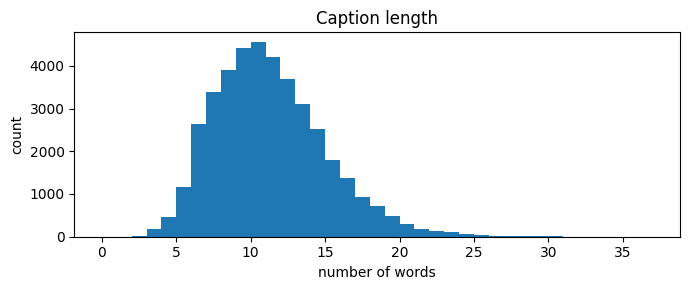

count    40455.0
mean        10.8
std          3.8
min          1.0
25%          8.0
50%         10.0
75%         13.0
max         36.0
Name: caption, dtype: float64

In [16]:
# 描述長度分佈 → 決定序列最大長度 CAP_MAX_LEN（含 <start> / <end>）
q4.plot_caption_lengths(captions_df)

In [17]:
# 以影像為單位切成 Train : Valid : Test = 7 : 2 : 1
cap_splits = q4.split_images(captions_df['image'], ratios=(0.7, 0.2, 0.1), random_state=RANDOM_STATE)
assert not (set(cap_splits['train']) & set(cap_splits['valid'])) and not (set(cap_splits['train']) & set(cap_splits['test']))

cap_summary = pd.DataFrame({
    'images': {k: len(v) for k, v in cap_splits.items()},
    'captions': {k: captions_df['image'].isin(set(v)).sum() for k, v in cap_splits.items()},
})
cap_summary['ratio'] = (cap_summary['images'] / cap_summary['images'].sum()).round(3)
display(cap_summary)

refs = {k: q4.references_by_image(captions_df, v) for k, v in cap_splits.items()}

,images,captions,ratio
train,5664,28320,0.7
valid,1618,8090,0.2
test,809,4045,0.1


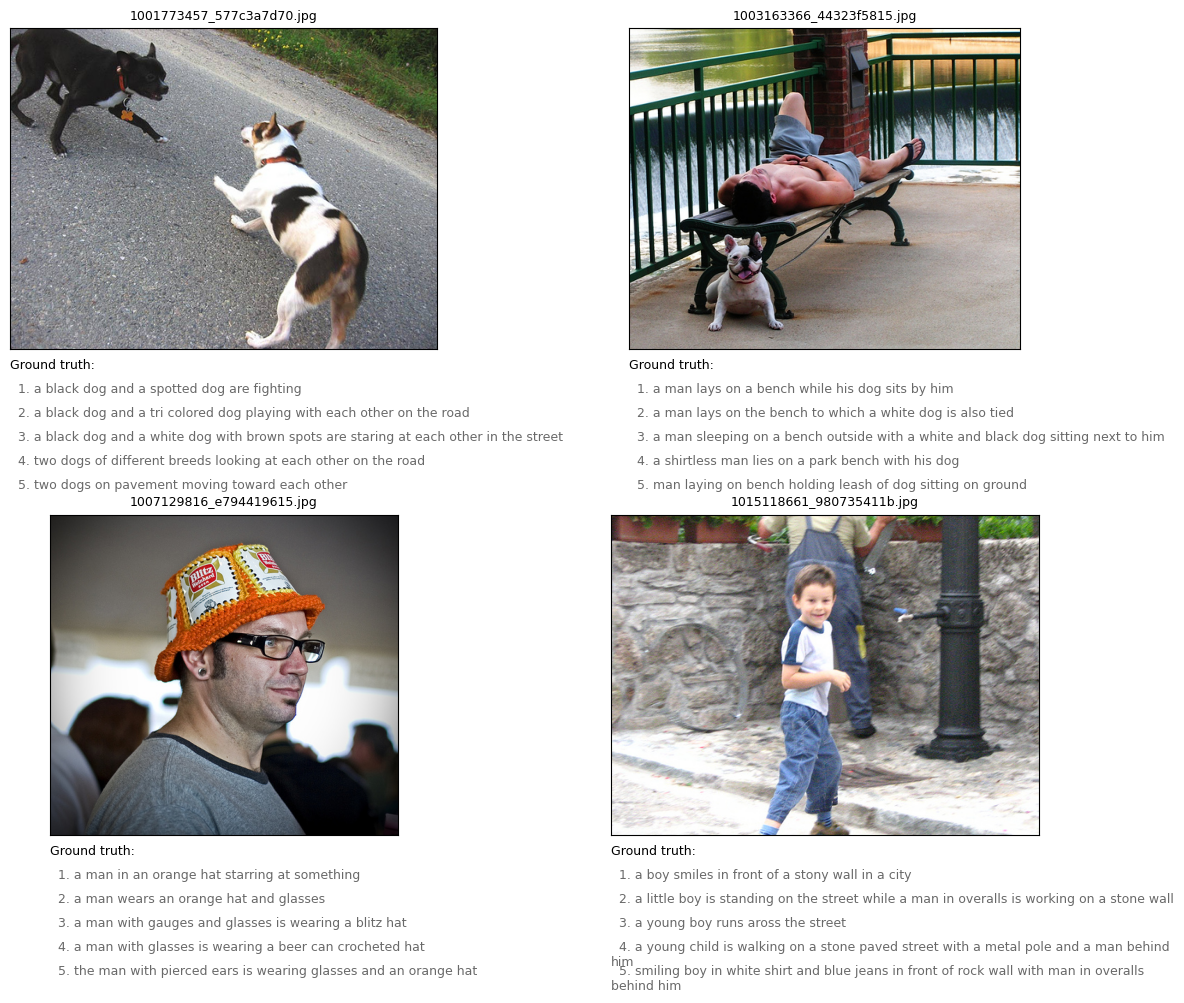

In [18]:
# 幾張訓練影像與它們的 5 句描述
q4.show_captions(cap_splits['train'][:4], FLICKR_IMG_DIR, refs['train'])

## 影像特徵抽取（Encoder）

- 使用 ImageNet 預訓練的 **ConvNeXt-Tiny**（凍結、不訓練），去掉分類頭，每張影像（Resize 224×224）輸出 **7×7×768** 的特徵網格 = 49 個區域特徵
- 保留空間網格（而不是只取一個全域向量），Decoder 才能透過 Attention 在產生每個詞時看影像的不同區域
- Encoder 凍結，特徵只需算一次，快取成 `data/flickr8k_convnext_tiny.npy`（float16，約 600 MB，以 memory-map 讀取）

In [19]:
%%time
all_images = sorted(captions_df['image'].unique())
features, feat_index = q4.extract_features(
    all_images, FLICKR_IMG_DIR, os.path.join(BASE_DIR, 'data', 'flickr8k_convnext_tiny.npy'), device,
)
print('特徵:', features.shape, features.dtype)

特徵: (8091, 49, 768) float16
CPU times: total: 0 ns
Wall time: 37.3 ms


In [20]:
CAP_MAX_LEN = 40          # 含 <start> / <end>，幾乎涵蓋所有描述
CAP_BATCH_SIZE = 64

cap_vocab = q4.Vocab(captions_df[captions_df['image'].isin(set(cap_splits['train']))]['caption'], min_freq=5)
print('字典大小:', len(cap_vocab))
example = captions_df['caption'][0]
print('原句:', example)
print('編碼:', cap_vocab.encode(example, CAP_MAX_LEN))
print('解碼:', cap_vocab.decode(cap_vocab.encode(example, CAP_MAX_LEN)))

cap_loaders = q4.build_dataloaders(captions_df, cap_splits, features, feat_index, cap_vocab,
                                   max_len=CAP_MAX_LEN, batch_size=CAP_BATCH_SIZE)
print({k: len(v.dataset) for k, v in cap_loaders.items()})

字典大小: 2477
原句: a child in a pink dress is climbing up a set of stairs in an entry way
編碼: [1, 4, 44, 5, 4, 92, 177, 8, 119, 53, 4, 392, 13, 382, 5, 29, 3, 664, 2]
解碼: a child in a pink dress is climbing up a set of stairs in an <unk> way
{'train': 28320, 'valid_loss': 8090, 'valid': 1618, 'test': 809}


## 模型：CNN Encoder + Transformer Decoder

```
影像 ─ ConvNeXt-Tiny(凍結) ─ 7×7×768 ─ Linear(768→512) + 位置編碼 ─ Transformer Encoder ×1 ─┐ memory
                                                                                            ↓ Cross-Attention
<start> a dog runs ─ 詞嵌入(512) + 位置編碼 ─ Transformer Decoder ×3（Masked Self-Attn → Cross-Attn → FFN）─ Linear ─ 下一個詞
```

- 訓練：**Teacher Forcing**（輸入 `<start> w1 … wn`，預測 `w1 … wn <end>`），每句描述都是一筆訓練樣本
- AdamW（lr = 3e-4）+ 1 epoch Warmup + Cosine Decay、Label Smoothing 0.1、Gradient Clipping
- 每個 epoch 在 Valid 上以 Greedy 產生描述計算 **BLEU-4**，選最佳權重並 Early Stopping（patience = 4）
- `RESUME = True`：`models/` 已有訓練好的權重就直接載入

In [21]:
# 重新載入 quiz4.py：修改 .py 之後只要重跑這格就會生效（不必重跑前面的 cell）
reload(q4)

RESUME = True         # True：models/ 已有權重就直接載入、跳過訓練（此時不會有進度條）
MODEL_DIR = os.path.join(BASE_DIR, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

q4.set_seed(RANDOM_STATE)
cap_model = q4.CaptionTransformer(len(cap_vocab), feat_dim=features.shape[2], n_regions=features.shape[1],
                                  d_model=512, nhead=8, num_layers=3, dim_ff=2048, dropout=0.1,
                                  max_len=CAP_MAX_LEN)
print(f'Caption model 可訓練參數量: {q4.count_parameters(cap_model) / 1e6:.2f} M')

cap_model, cap_hist = q4.train_model(
    cap_model, cap_loaders, cap_vocab, refs['valid'], device,
    epochs=20, lr=3e-4, weight_decay=0.01, warmup_epochs=1, label_smoothing=0.1, patience=4,
    save_path=os.path.join(MODEL_DIR, 'flickr8k_caption.pt'), resume=RESUME,
)

Caption model 可訓練參數量: 18.74 M
載入已訓練的權重: c:\Users\Alan\python\MMIP\week4\models\flickr8k_caption.pt（RESUME=True，跳過訓練，因此不會有進度條）


c:\Users\Alan\anaconda3\envs\virtual_env\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


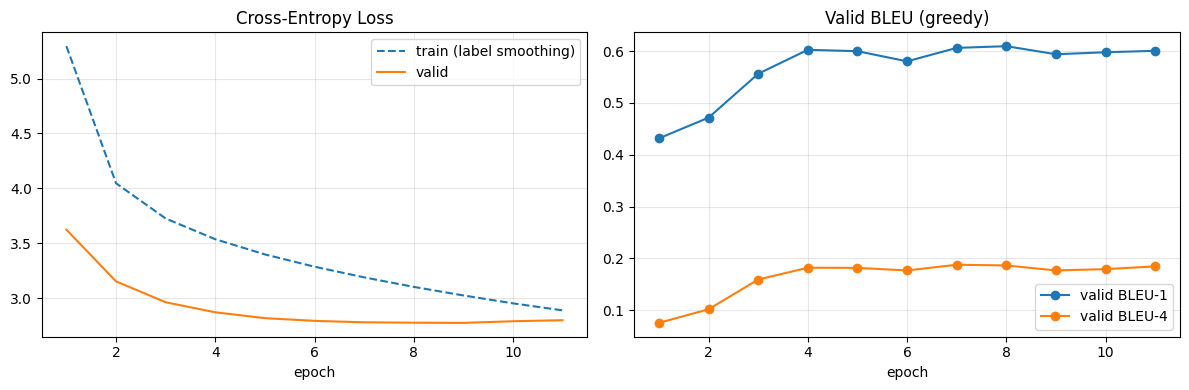

In [22]:
q4.plot_history(cap_hist)

## 測試集：產生描述與量化評估

產生描述的兩種方式：
- **Greedy**：每一步直接選機率最高的詞
- **Beam Search（beam = 3）**：每一步保留累積機率最高的 3 條候選句，最後選整句分數最高的（加長度懲罰，避免偏好短句）

評估指標（每張測試影像都以 5 句人工描述當參考答案）：
- **BLEU-1 ~ BLEU-4**：模型描述與參考答案的 n-gram（1~4 個連續詞）重疊程度，BLEU-4 最常被拿來比較
- **BERTScore（P / R / F1）**：用 BERT（`distilbert-base-uncased`）的 contextual embedding 比較語意相似度，換句話說或同義詞也能得分；分數經 baseline rescale，0 約等於隨機句子的相似度

In [23]:
import time

# 分別記錄 Greedy / Beam Search 產生整個測試集描述所花的時間（不含 BLEU / BERTScore 計算）
decode_settings = {
    'Greedy': dict(method='greedy'),
    'Beam-3': dict(method='beam', beam_size=3),
}
test_preds, decode_time = {}, {}
for name, kwargs in decode_settings.items():
    if device.type == 'cuda':
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    test_preds[name] = q4.generate_captions(cap_model, cap_loaders['test'], cap_vocab, device, **kwargs)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    decode_time[name] = time.perf_counter() - t0
    print(f'{name}: {len(test_preds[name])} 張影像，共 {decode_time[name]:.2f} s'
          f'（平均 {decode_time[name] / len(test_preds[name]) * 1000:.2f} ms / 張）')

cap_scores = pd.DataFrame({name: q4.evaluate_captions(p, refs['test'], device=device)
                           for name, p in test_preds.items()}).T.round(4)
cap_scores['time (s)'] = pd.Series(decode_time).round(2)
cap_scores['ms / image'] = pd.Series({k: v / len(test_preds[k]) * 1000 for k, v in decode_time.items()}).round(2)
display(cap_scores)

Generating (greedy):   0%|          | 0/13 [00:00<?, ?it/s]

c:\Users\Alan\anaconda3\envs\virtual_env\Lib\site-packages\torch\nn\functional.py:5849: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Greedy: 809 張影像，共 3.72 s（平均 4.59 ms / 張）


Generating (beam):   0%|          | 0/13 [00:00<?, ?it/s]

Beam-3: 809 張影像，共 39.41 s（平均 48.72 ms / 張）


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,BLEU-1,BLEU-2,BLEU-3,BLEU-4,BERTScore-P,BERTScore-R,BERTScore-F1,time (s),ms / image
Greedy,0.5866,0.4081,0.2710,0.1781,0.5981,0.5679,0.5733,3.72,4.59
Beam-3,0.6184,0.4422,0.3057,0.2095,0.6082,0.5746,0.5815,39.41,48.72


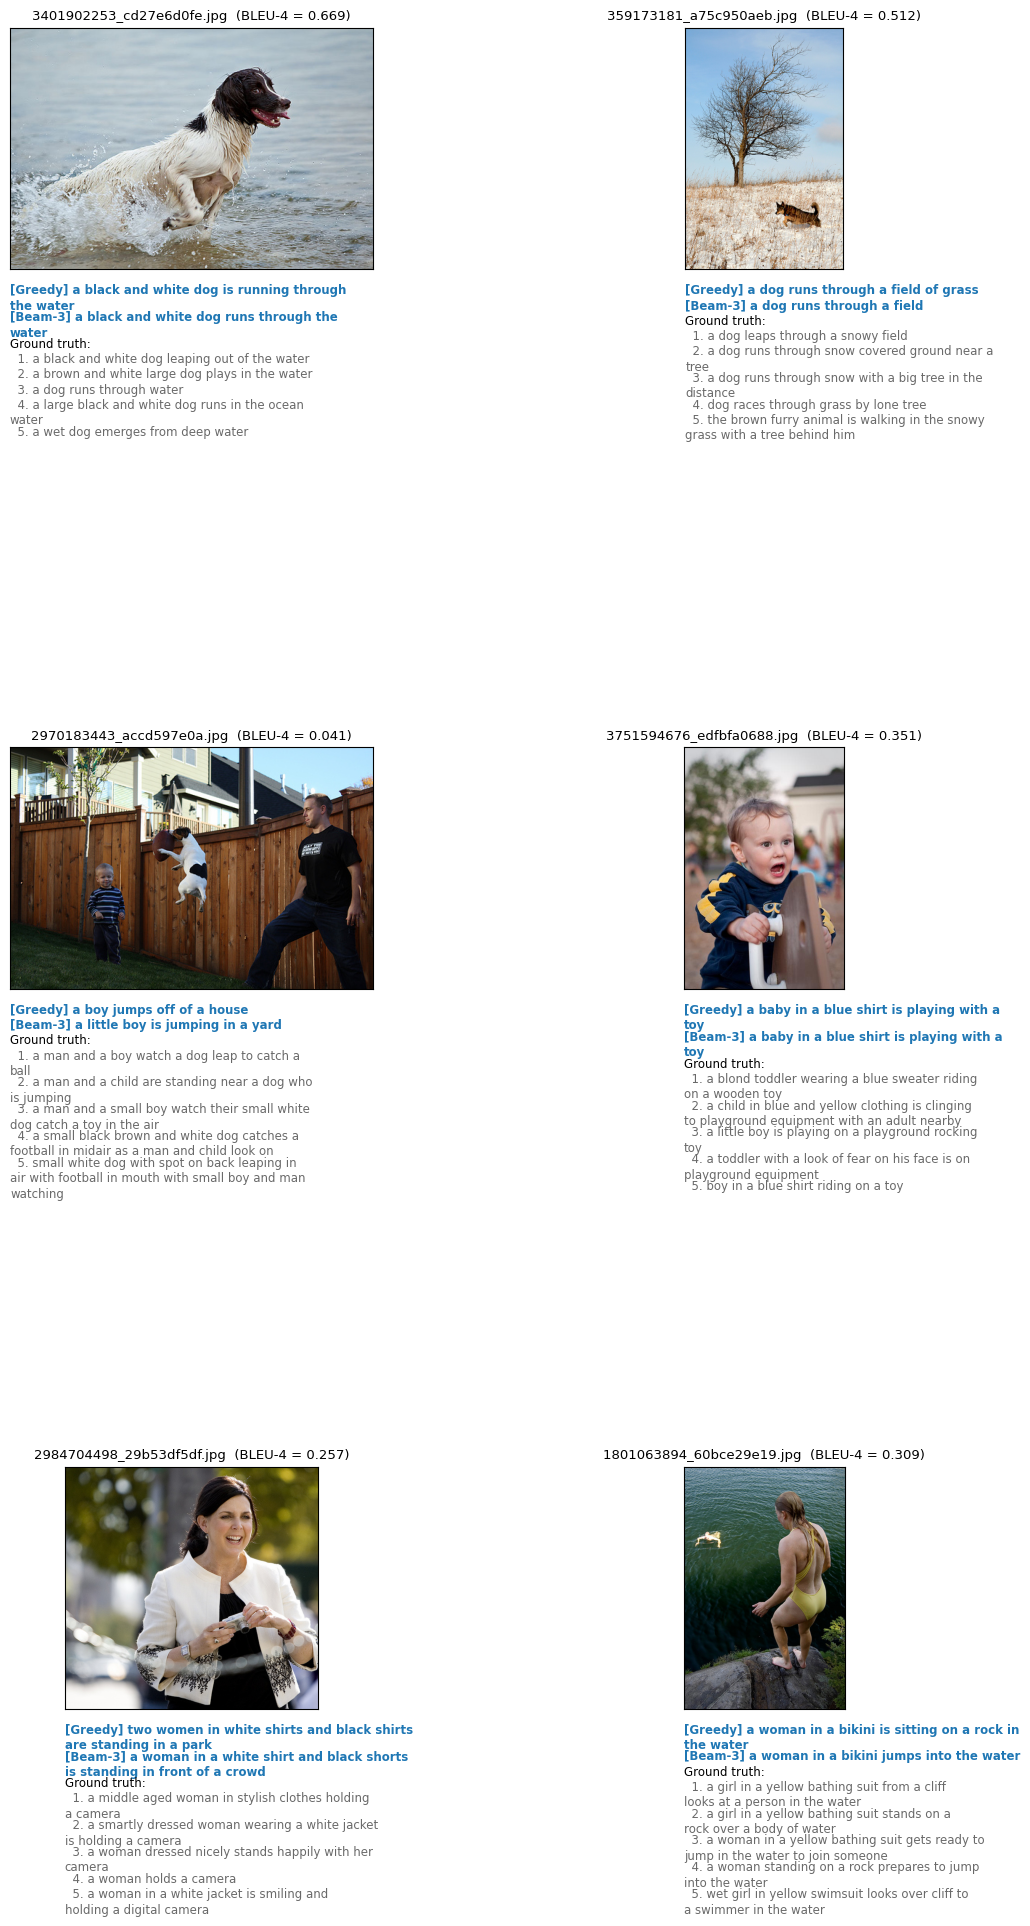

In [36]:
# 隨機挑選測試影像：模型描述（藍）vs. 正確描述（灰）
rng = np.random.default_rng(RANDOM_STATE)
sample_images = list(rng.choice(cap_splits['test'], 6, replace=False))
sent_bleu = q4.sentence_bleu4(test_preds['Beam-3'], refs['test'])
q4.show_captions(sample_images, FLICKR_IMG_DIR, refs['test'], test_preds, scores=sent_bleu)

===== BLEU-4 最高 =====


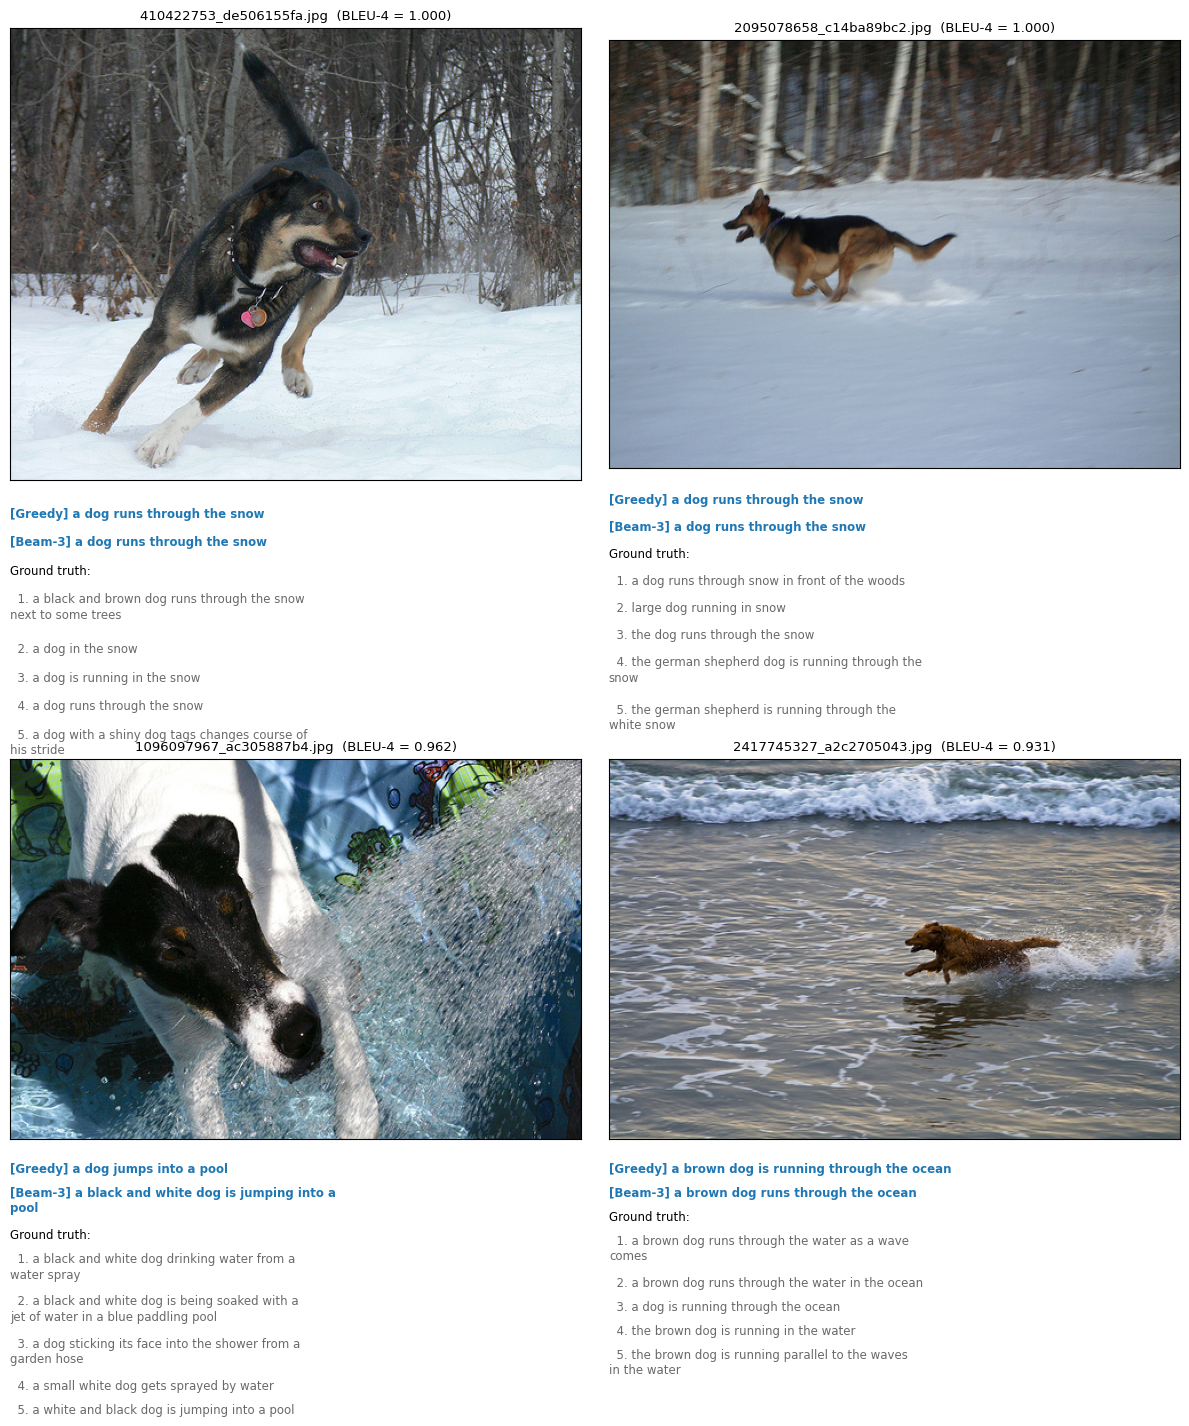

===== BLEU-4 最低 =====


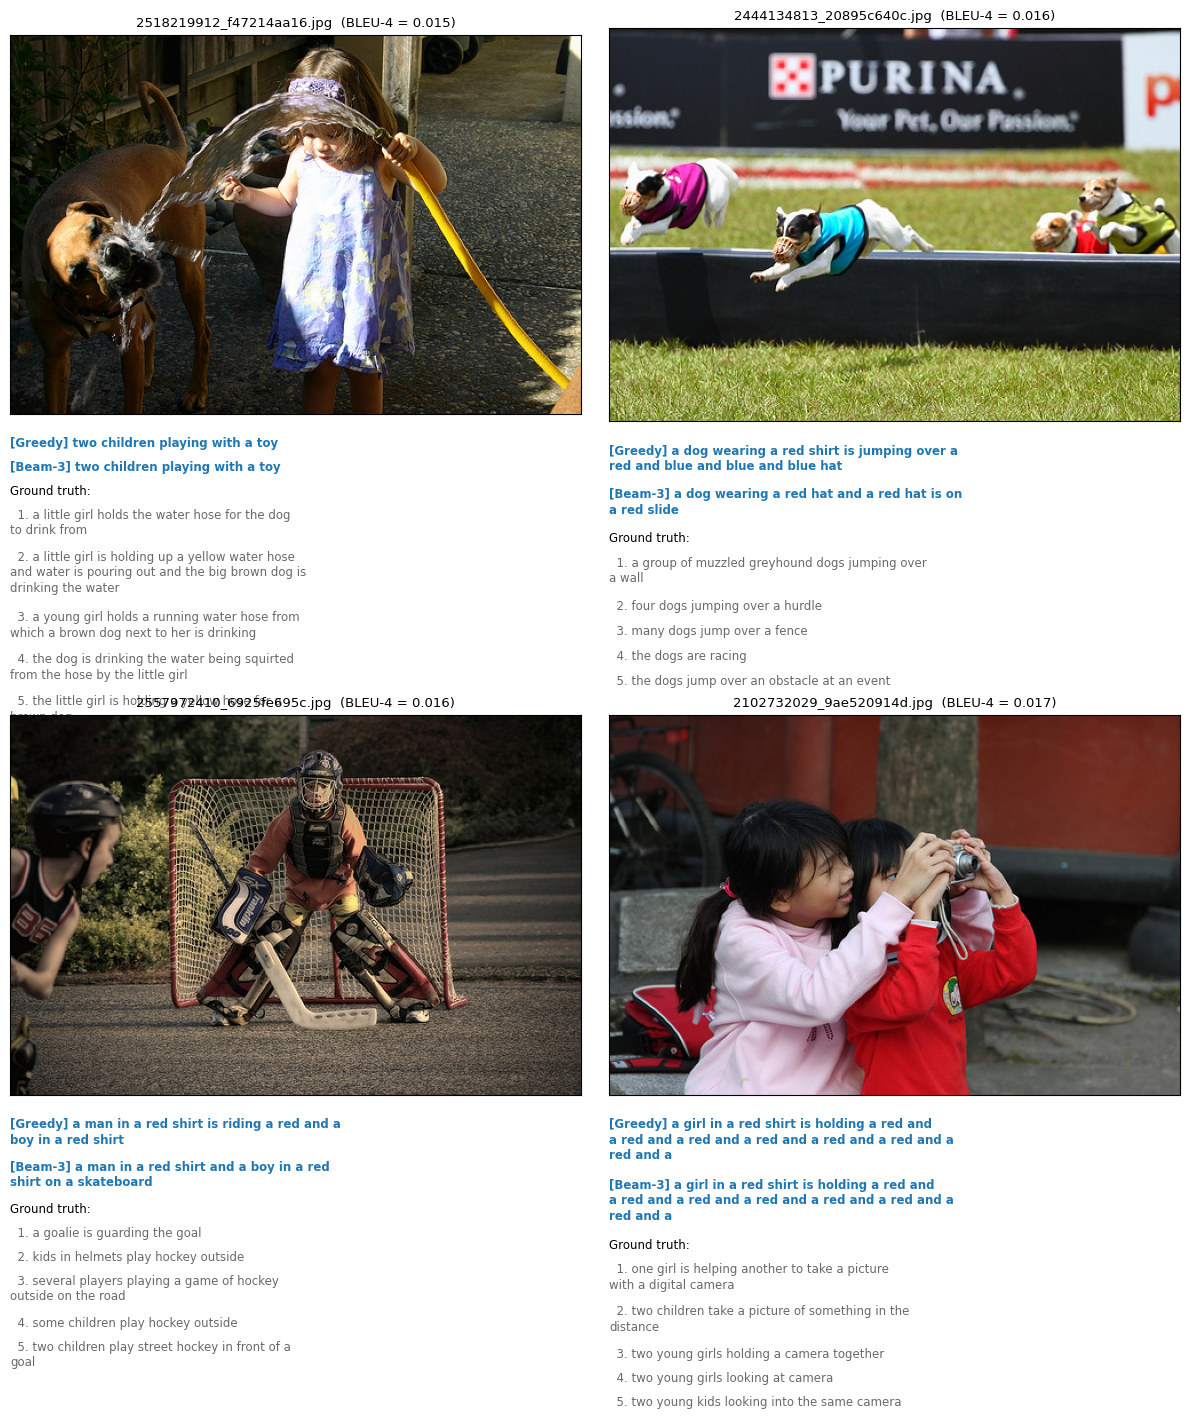

In [37]:
# 依單句 BLEU-4 排序：模型描述得最好 / 最差的測試影像
ranked = sorted(sent_bleu, key=sent_bleu.get)
print('===== BLEU-4 最高 =====')
q4.show_captions(ranked[-4:][::-1], FLICKR_IMG_DIR, refs['test'], test_preds, scores=sent_bleu)
print('===== BLEU-4 最低 =====')
q4.show_captions(ranked[:4], FLICKR_IMG_DIR, refs['test'], test_preds, scores=sent_bleu)

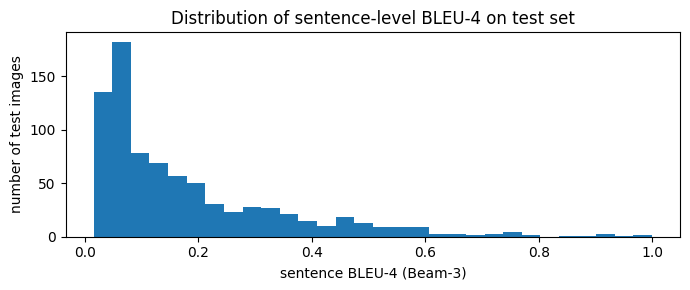

In [27]:
# 單句 BLEU-4 分佈
plt.figure(figsize=(7, 3))
plt.hist(list(sent_bleu.values()), bins=30)
plt.xlabel('sentence BLEU-4 (Beam-3)')
plt.ylabel('number of test images')
plt.title('Distribution of sentence-level BLEU-4 on test set')
plt.tight_layout()
plt.show()